## Expt.-8: Clustering of Countries with World Bank API
### Agastya Shetty
### Roll no. 63
### Batch 2



In [3]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from scipy.cluster.hierarchy import dendrogram, linkage

In [4]:
def fetch_indicator(code, year = "2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data = {}
    for item in response:
        country = item["country"]["value"]
        value=item["value"]
        if value is not None:
            data[country] = value

    return pd.Series(data, name=code)

In [5]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [13]:
df=pd.concat ([gdp, pop, life, lit], axis=1)
df.columns=["GDP", "Population", "LifeExpectancy", "Literacy"]
df.dropna(inplace=True)
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [14]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

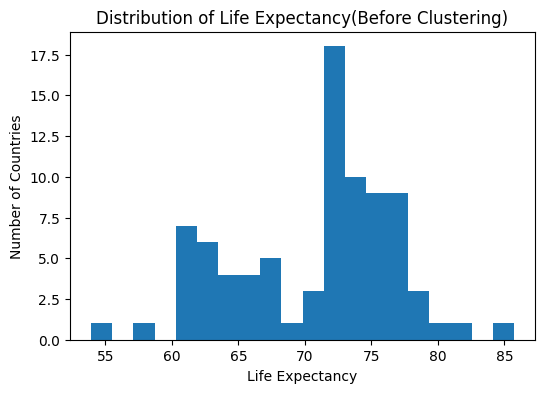

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins = 20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of Life Expectancy(Before Clustering)")
plt.show()

## Part 2 : Elbow Method

k	WCSS
1 	 336.00000000000006
2 	 206.43717192603808
3 	 142.06028324967596
4 	 122.46400641421171
5 	 68.71234707726028
6 	 56.092718405819106
7 	 51.08265517326418
8 	 41.70851027024395
9 	 31.213863029560223
10 	 27.04725098650771


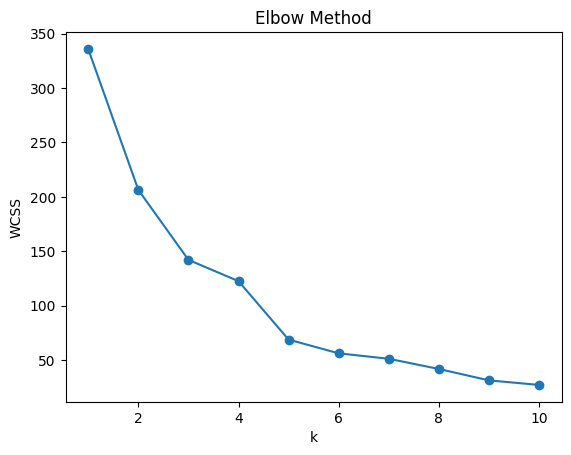

In [26]:
WCSS = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    WCSS.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i+1, "\t", WCSS[i])

plt.plot(range(1,11), WCSS, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Part 3 Clustering Algorithm

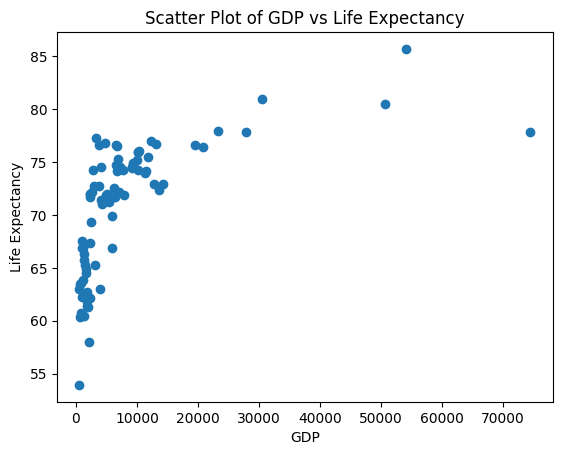

In [27]:
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Scatter Plot of GDP vs Life Expectancy")
plt.show()

In [28]:
kmeans= KMeans(n_clusters=3, random_state=0)
labels_km=kmeans.fit_predict(X_scaled)
df["KMeansCluster"] = labels_km

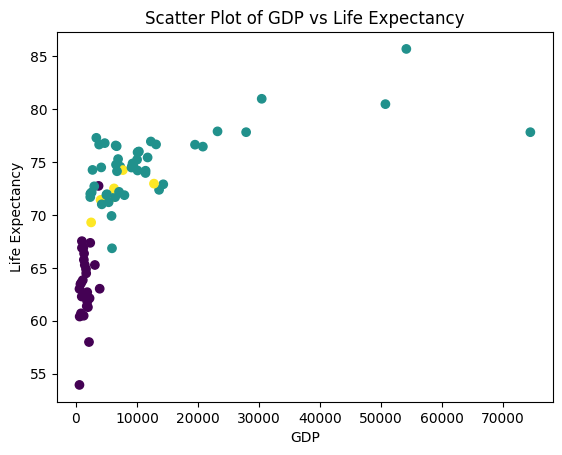

In [29]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Scatter Plot of GDP vs Life Expectancy")
plt.show()

In [30]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)
df["HierarchicalCLuster"]=labels_hc

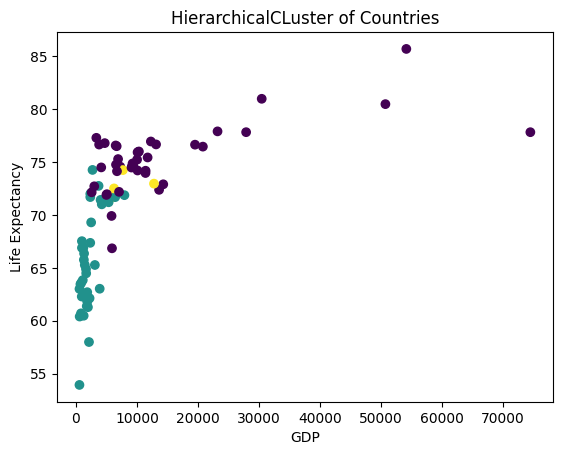

In [32]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_hc)
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("HierarchicalCLuster of Countries")
plt.show()

In [33]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1601.971896  4.854521e+08       63.478867  66.779721
1              12288.225626  4.669122e+08       74.753258  92.910908
2               6437.349751  5.501554e+09       71.975830  84.851687


In [34]:
country_name = "India"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("Cluster:", result["KMeansCluster"])
print("HierarchicalCLuster:", result["HierarchicalCLuster"])

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
Cluster: 1.0
HierarchicalCLuster: 1.0


In [35]:
country_name = "North America"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("Cluster:", result["KMeansCluster"])
print("HierarchicalCLuster:", result["HierarchicalCLuster"])

Country: North America
GDP per capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
Cluster: 1.0
HierarchicalCLuster: 0.0


In [36]:
country_name = "Brazil"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("Cluster:", result["KMeansCluster"])
print("HierarchicalCLuster:", result["HierarchicalCLuster"])

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
Cluster: 1.0
HierarchicalCLuster: 0.0


In [37]:
country_name = "Viet Nam"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("Cluster:", result["KMeansCluster"])
print("HierarchicalCLuster:", result["HierarchicalCLuster"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
Cluster: 1.0
HierarchicalCLuster: 0.0


In [38]:
country_name = "Bahrain"

result = df.loc[country_name]

print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("Cluster:", result["KMeansCluster"])
print("HierarchicalCLuster:", result["HierarchicalCLuster"])

Country: Bahrain
GDP per capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
Cluster: 1.0
HierarchicalCLuster: 0.0


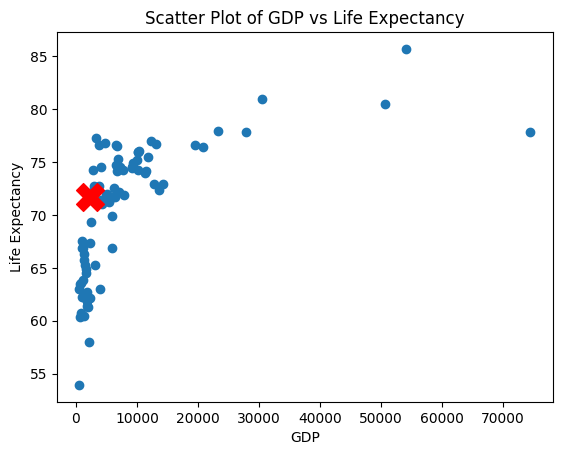

In [39]:
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP")
plt.ylabel("Life Expectancy")
plt.title("Scatter Plot of GDP vs Life Expectancy")
india = df.loc["India"]
plt.scatter(india["GDP"], india["LifeExpectancy"],s=400, color="red", marker='X')
plt.show()